In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob

import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns

from dfmodel import DigitalFamilyBinary
from dpks import QuantMatrix

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [3]:
proteomics_data_train = pd.read_csv(
    "../1_proteomics_data/protein_test_filtered.tsv"
    , sep="\t"
)


clinical_data_train = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']


In [4]:
proteomics_data_test = pd.read_csv(
    "../1_proteomics_data/protein_val_filtered.tsv"
    , sep="\t"
)
clinical_data_test = pd.read_csv(
    "../0_clinical_data/design_matrix_validation.tsv",
    sep='\t'
)
clinical_data_test['sample'] = clinical_data_test['injection']


In [5]:
clinical_data_train['survival_30_day'] = np.where(clinical_data_train['survival_days'] <= 30, 1, 0)
clinical_data_test['survival_30_day'] = np.where(clinical_data_test['survival_days'] <= 30, 1, 0)


clinical_data_train['future_od'] = np.where(
    (clinical_data_train['sofa_score_increase_day2'] > 1) & (clinical_data_train['sofa_score_increase_day3'] > 1), 1, 0
)
clinical_data_test['future_od'] = np.where(
    (clinical_data_test['sofa_score_increase_day2'] > 1) & (clinical_data_test['sofa_score_increase_day3'] > 1), 1, 0
)

In [6]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)
quant_matrix_test = preprocess_data(proteomics_data_test, design_matrix=clinical_data_test)

In [7]:
selected_features = pd.read_csv(
    "../4_high_risk_sepsis_df/sepsis_feature_importances.tsv",
    sep="\t",
)['feature'].to_list()

In [8]:
training_data, _ = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))
testing_data, _ = quant_matrix_test.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))

In [9]:
selected_features

['VWF_HUMAN',
 'SAA2_HUMAN',
 'CYTC_HUMAN',
 'KLKB1_HUMAN',
 'IBP3_HUMAN',
 'LBP_HUMAN',
 'VCAM1_HUMAN',
 'AACT_HUMAN',
 'APOM_HUMAN',
 'FGL1_HUMAN']

In [10]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
training_data[selected_features] = protein_scaler.fit_transform(training_data[selected_features])

testing_data[selected_features] = protein_scaler.transform(testing_data[selected_features])

In [11]:
training_data = clinical_data_train.set_index("injection").join(
    training_data
).reset_index()

testing_data = clinical_data_test.set_index("injection").join(
    testing_data
).reset_index()

In [12]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=selected_features)

In [13]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=True)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="verified_infection", bootstrap=True)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=selected_features, target_column="future_od", bootstrap=True)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
training_data['ICU'] = df_estimator.predict(training_data, features=selected_features, target_column="critical_care", bootstrap=True)

In [14]:
from scipy import stats
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

def plot_results(X_input, bootstrap_data):

    bootstrap_counts = []


    for bootstrap_iteration in list(bootstrap_data.keys()):


        mort_range = X_input[bootstrap_iteration].unique()
        mort_range.sort()
        actual_mort = []
        #mort_range = mort_range[:-1]
        counts_per_bin = []
        for val in mort_range:

            counts = X_input[X_input[bootstrap_iteration] == val]['sepsis_or_septic_shock'].value_counts()
            actual_mort.append(counts.get(1, 0) / (counts.get(0, 0) + counts.get(1, 0)))
            counts_per_bin.append(counts.sum())

        estimated_mort = pd.DataFrame(
            {
                "Actual Sepsis Rate": actual_mort,
                "Estimated Sepsis Rate": mort_range,
                "Counts": counts_per_bin
            }
        )

        bootstrap_counts.append(estimated_mort)

    estimated_sepsis = pd.concat(bootstrap_counts)

    # linreg = LinearRegression()

    # linreg.fit(estimated_sepsis[['Estimated Sepsis Rate']], estimated_sepsis[['Actual Sepsis Rate']])

    linregress_results = linregress(estimated_sepsis[['Estimated Sepsis Rate']].values.ravel(), estimated_sepsis[['Actual Sepsis Rate']].values.ravel())

    predictions = linregress_results.intercept + linregress_results.slope*estimated_sepsis[['Estimated Sepsis Rate']].values.ravel()

    corr, pval = pearsonr(
        estimated_sepsis[['Estimated Sepsis Rate']].values.ravel(), estimated_sepsis[['Actual Sepsis Rate']].values.ravel()
    )

    return estimated_sepsis, linregress_results, predictions, corr, pval

In [15]:
testing_data['Sepsis Protein Prob'] = df_estimator.predict(
    testing_data[selected_features],
    features=selected_features,
    target_column="sepsis_or_septic_shock",
    bootstrap=True
)

X_test_results = pd.concat([testing_data,  df_estimator.bootstrap_results_df], axis=1)

protein_estimated_sepsis, protein_linregress_results, protein_predictions, protein_corr, protein_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


In [16]:
sepsis_bootstrap_df_first = df_estimator.bootstrap_results_df.copy()
sepsis_bootstrap_df_first = sepsis_bootstrap_df_first.join(
    testing_data
)


In [17]:
X_test_results['Sepsis Diagnosis Probability'] = X_test_results[df_estimator.bootstrap_columns].mean(axis=1)

In [18]:
protein_estimated_sepsis.to_csv(
    "val_eval.tsv",
    sep="\t",
    index=False
)

In [19]:
proteomics_data_train = pd.read_csv(
    "../1_proteomics_data/protein_test_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

# proteomics_data_test = pd.read_csv(
#     "../1_proteomics_data/protein_test_filtered.tsv"
#     , sep="\t"
# )
# clinical_data_test = pd.read_csv(
#     "../0_clinical_data/design_matrix_test.tsv",
#     sep='\t'
# )


proteomics_data_hero = pd.read_csv(
    "../1_proteomics_data/protein_hero_filtered.tsv",
    sep='\t'
)
clinical_data_hero = pd.read_csv(
    "../0_clinical_data/design_matrix_hero.tsv",
    sep='\t'
)

clinical_data_hero['sample'] = clinical_data_hero['injection']
#clinical_data_hero = clinical_data_hero[clinical_data_hero['injection'].isin(proteomics_data_hero.columns)].copy().reset_index()


clinical_data_test['sample'] = clinical_data_test['injection']


In [20]:
clinical_data_train = pd.concat(
    [clinical_data_train, clinical_data_hero],
    ignore_index=True
)

proteomics_data_train = proteomics_data_train.set_index("Protein").join(
    proteomics_data_test.set_index("Protein")
).join(
    proteomics_data_hero.set_index("Protein")
).reset_index()

In [21]:
proteomics_data_test = pd.read_csv(
    "../1_proteomics_data/protein_val_filtered.tsv"
    , sep="\t"
)
clinical_data_test = pd.read_csv(
    "../0_clinical_data/design_matrix_validation.tsv",
    sep='\t'
)
clinical_data_test['sample'] = clinical_data_test['injection']
#clinical_data_test = clinical_data_test[clinical_data_test['injection'].isin(proteomics_data_test.columns)].copy().reset_index()


In [22]:
clinical_data_train['survival_30_day'] = np.where(clinical_data_train['survival_days'] <= 30, 1, 0)
clinical_data_test['survival_30_day'] = np.where(clinical_data_test['survival_days'] <= 30, 1, 0)


clinical_data_train['future_od'] = np.where(
    (clinical_data_train['sofa_score_increase_day2'] > 1) & (clinical_data_train['sofa_score_increase_day3'] > 1), 1, 0
)
clinical_data_test['future_od'] = np.where(
    (clinical_data_test['sofa_score_increase_day2'] > 1) & (clinical_data_test['sofa_score_increase_day3'] > 1), 1, 0
)

In [23]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)
quant_matrix_test = preprocess_data(proteomics_data_test, design_matrix=clinical_data_test)

In [24]:
selected_features = pd.read_csv(
    "../4_high_risk_sepsis_df/sepsis_feature_importances.tsv",
    sep="\t",
)['feature'].to_list()

In [25]:
training_data, _ = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))
testing_data, _ = quant_matrix_test.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))

In [26]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
training_data[selected_features] = protein_scaler.fit_transform(training_data[selected_features])

testing_data[selected_features] = protein_scaler.transform(testing_data[selected_features])

In [27]:
training_data = clinical_data_train.set_index("injection").join(
    training_data
).reset_index()

testing_data = clinical_data_test.set_index("injection").join(
    testing_data
).reset_index()

In [28]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=selected_features)

In [29]:
df_estimator.fit(training_data, features=selected_features)

testing_data['Sepsis Protein Prob'] = df_estimator.predict(
    testing_data[selected_features],
    features=selected_features,
    target_column="sepsis_or_septic_shock",
    bootstrap=True
)

X_test_results = pd.concat([testing_data, df_estimator.bootstrap_results_df], axis=1)


combined_estimated_sepsis, combined_linregress_results, combined_predictions, combined_corr, combined_pval = plot_results(X_test_results, df_estimator.bootstrap_results_df)


In [30]:
sepsis_bootstrap_df_combined = df_estimator.bootstrap_results_df.copy()
sepsis_bootstrap_df_combined = sepsis_bootstrap_df_combined.join(
    testing_data
)

In [31]:
X_test_results['Sepsis Diagnosis Probability'] = X_test_results[df_estimator.bootstrap_columns].mean(axis=1)

In [32]:

combined_estimated_sepsis.to_csv(
    "combined_eval.tsv",
    sep="\t",
    index=False
)

In [33]:
def sem(x):
    return x.std() / np.sqrt(len(x))

In [34]:
protein_result = protein_estimated_sepsis[['Actual Sepsis Rate', 'Estimated Sepsis Rate']].groupby('Estimated Sepsis Rate').agg(
    mean_values=('Actual Sepsis Rate', 'mean'),
    sem_values=('Actual Sepsis Rate', sem)
).reset_index()

print(protein_result)

    Estimated Sepsis Rate  mean_values  sem_values
0                     0.0     0.200000    0.068599
1                     0.1     0.188209    0.010475
2                     0.2     0.326619    0.003215
3                     0.3     0.299824    0.004378
4                     0.4     0.346353    0.002810
5                     0.5     0.509201    0.002502
6                     0.6     0.536398    0.001784
7                     0.7     0.585687    0.001800
8                     0.8     0.732296    0.001241
9                     0.9     0.770107    0.001051
10                    1.0     0.748352    0.001456


In [35]:
combined_result = combined_estimated_sepsis[['Actual Sepsis Rate', 'Estimated Sepsis Rate']].groupby('Estimated Sepsis Rate').agg(
    mean_values=('Actual Sepsis Rate', 'mean'),
    sem_values=('Actual Sepsis Rate', sem)
).reset_index()

print(combined_result)

    Estimated Sepsis Rate  mean_values  sem_values
0                     0.0     0.784296    0.005536
1                     0.1     0.131064    0.001434
2                     0.2     0.324839    0.001850
3                     0.3     0.408802    0.001638
4                     0.4     0.461190    0.001595
5                     0.5     0.674635    0.001282
6                     0.6     0.693041    0.001005
7                     0.7     0.732877    0.001032
8                     0.8     0.786248    0.001197
9                     0.9     0.756415    0.001869
10                    1.0     0.601500    0.002970


In [36]:
combined_result['Label'] = "Combined Database"
protein_result['Label'] = "Testing Database"

In [37]:
cr_df = pd.concat(
    [combined_result, protein_result]
)

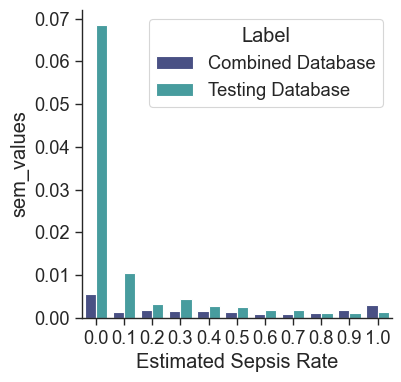

In [38]:
import matplotlib.pyplot as plt

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)

fig, ax = plt.subplots()

sns.barplot(
    data=cr_df,
    x="Estimated Sepsis Rate",
    y="sem_values",
    hue="Label",
    orient="v",
    ax=ax,
    palette="mako",
    legend=True
)

sns.despine()
fig.set_size_inches((4, 4))

In [39]:
fig.savefig(
    "standard_error.pdf", dpi=300, bbox_inches="tight"
)

In [41]:
#training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=True)
#training_data['Infection Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="verified_infection", bootstrap=True)
#training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=selected_features, target_column="future_od", bootstrap=True)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
#training_data['ICU'] = df_estimator.predict(training_data, features=selected_features, target_column="critical_care", bootstrap=True)

In [42]:
#testing_data['Sepsis Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=True)
#testing_data['Infection Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="verified_infection", bootstrap=True)
testing_data['30 Day Mortality'] = df_estimator.predict(testing_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
mortality_bootstrap_df = df_estimator.bootstrap_results_df.copy()
mortality_bootstrap_df = mortality_bootstrap_df.join(
    testing_data
)

mortality_bootstrap_df.to_csv(
    "combined_mortality_bootstrap_results_df.csv",
)

In [43]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [44]:
display_columns = [
    #"Sepsis Rates",
    #"Infection Rates",
    "30 Day Mortality"
]

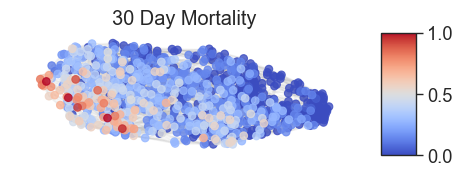

In [45]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    gridspec_kw={'width_ratios': [1, 0.1]}
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    ordered_nodes = list(training_data.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)



sm = plt.cm.ScalarMappable(cmap="coolwarm")
cbar = fig.colorbar(sm, cax=axs[-1], orientation="vertical")


fig.set_size_inches(((8.27) * .6 , 2))
plt.tight_layout()

fig.savefig(
    "mort_df_hero_map.pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)